# Week 06 · Day 01

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import pearsonr, spearmanr, bootstrap
from pathlib import Path

In [2]:
Path("Data").mkdir(parents=True, exist_ok=True)
Path("graphs/partb").mkdir(parents=True, exist_ok=True)
Path("graphs/partc").mkdir(parents=True, exist_ok=True)
Path("graphs/parte").mkdir(parents=True, exist_ok=True)

##  PART A — build the dataset (unmodified, exact spec)

In [3]:
rng = np.random.default_rng(seed=21)
n = 600

class_section = rng.choice(["A", "B", "C"], size=n, p=[0.34, 0.33, 0.33])
study_hours = rng.normal(10, 3.5, size=n).clip(0, None).round(1)
sleep_hours = rng.normal(7, 1.2, size=n).clip(3, 10).round(1)
attendance_pct = rng.normal(85, 10, size=n).clip(40, 100).round(1)

noise = rng.normal(0, 8, size=n)
section_bonus = pd.Series(class_section).map({"A": 0, "B": 0, "C": 4}).values
exam_score = (50 + 2.6*study_hours + 0.15*attendance_pct + section_bonus + noise).clip(0, 100).round(1)

students = pd.DataFrame({
    "student_id": np.arange(1, n + 1),
    "class_section": class_section,
    "study_hours_per_week": study_hours,
    "sleep_hours_per_night": sleep_hours,
    "attendance_pct": attendance_pct,
    "exam_score": exam_score,
})


students.to_csv("Data/raw_students.csv", index=False)

### Diagnosis

In [4]:
students.head()

,student_id,class_section,study_hours_per_week,sleep_hours_per_night,attendance_pct,exam_score
0,1,C,11.0,7.3,89.4,100.0
1,2,B,9.1,7.7,72.4,72.2
2,3,C,2.2,8.5,84.6,67.2
3,4,A,13.5,7.5,83.4,100.0
4,5,B,11.0,5.4,100.0,100.0


In [5]:
students.describe()

,student_id,study_hours_per_week,sleep_hours_per_night,attendance_pct,exam_score
count,600.000000,600.000000,600.000000,600.000000,600.000000
mean,300.500000,10.089333,7.046000,85.583000,88.605000
std,173.349358,3.407213,1.122787,9.137597,10.205279
min,1.000000,0.400000,3.400000,62.000000,58.900000
25%,150.750000,7.700000,6.275000,78.900000,81.750000
50%,300.500000,10.000000,7.100000,85.700000,90.200000
75%,450.250000,12.500000,7.800000,92.325000,98.700000
max,600.000000,21.900000,10.000000,100.000000,100.000000


In [6]:
students.shape

(600, 6)

In [7]:
students.info()

<class 'pandas.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             600 non-null    int64  
 1   class_section          600 non-null    str    
 2   study_hours_per_week   600 non-null    float64
 3   sleep_hours_per_night  600 non-null    float64
 4   attendance_pct         600 non-null    float64
 5   exam_score             600 non-null    float64
dtypes: float64(4), int64(1), str(1)
memory usage: 28.3 KB


In [8]:
print("Students ------- Missing Values")
students.isna().sum()

Students ------- Missing Values


student_id               0
class_section            0
study_hours_per_week     0
sleep_hours_per_night    0
attendance_pct           0
exam_score               0
dtype: int64

In [9]:
students.duplicated().sum()

np.int64(0)

In [10]:
students["class_section"].value_counts()

class_section
A    212
B    198
C    190
Name: count, dtype: int64

## PART B — genuine relationships, correctly built and written up

### Kata 2: Relationship Chart (Study Hours vs. Exam Score)

**A relationship asks:**

"As X increases, does Y tend to increase or decrease?"

In [11]:
r_study, p_study = pearsonr(students["study_hours_per_week"], students["exam_score"])

In [12]:
print("Pearson correlation")
print(f"{r_study:.2f}")

Pearson correlation
0.69


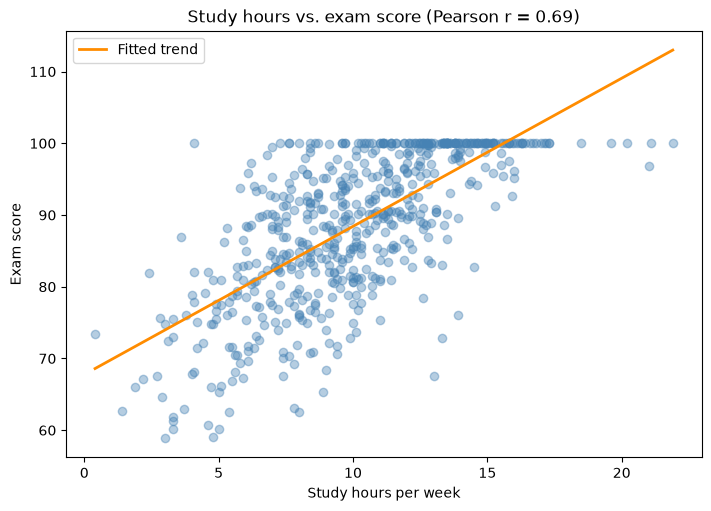

In [13]:

fig, ax = plt.subplots(figsize=(7, 5), layout="constrained")
ax.scatter(students["study_hours_per_week"], students["exam_score"], alpha=0.4, color="steelblue")
m, b = np.polyfit(students["study_hours_per_week"], students["exam_score"], 1)
xs = np.linspace(students["study_hours_per_week"].min(), students["study_hours_per_week"].max(), 100)
ax.plot(xs, m * xs + b, color="darkorange", linewidth=2, label="Fitted trend")
ax.set_xlabel("Study hours per week")
ax.set_ylabel("Exam score")
ax.set_title(f"Study hours vs. exam score (Pearson r = {r_study:.2f})")
ax.legend()
fig.savefig("graphs/partb/step2_study_vs_score.png", dpi=150)
plt.show()

In [14]:
finding_study = (
    f"Study hours per week and exam score show a strong positive relationship "
    f"(Pearson r = {r_study:.3f}, n = {n}): students who study more tend to score higher."
)
#print(f"Study hours show a positive relationship with exam score, "f"with Pearson r = {study_exam_r:.3f}.")
finding_study

'Study hours per week and exam score show a strong positive relationship (Pearson r = 0.689, n = 600): students who study more tend to score higher.'

### Kata 3: Null-Relationship Chart (Sleep Hours vs. Exam Score)

In [15]:
r_sleep, p_sleep = pearsonr(students["sleep_hours_per_night"], students["exam_score"])
print("Pearson correlation")
print(f"{r_sleep:.3f}")

Pearson correlation
-0.022


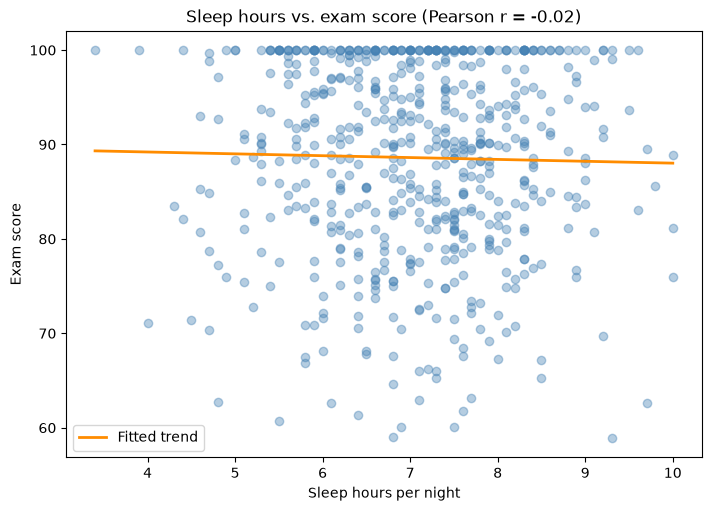

In [16]:
fig, ax = plt.subplots(figsize=(7, 5), layout="constrained")
ax.scatter(students["sleep_hours_per_night"], students["exam_score"], alpha=0.4, color="steelblue")
m2, b2 = np.polyfit(students["sleep_hours_per_night"], students["exam_score"], 1)
xs2 = np.linspace(students["sleep_hours_per_night"].min(), students["sleep_hours_per_night"].max(), 100)
ax.plot(xs2, m2 * xs2 + b2, color="darkorange", linewidth=2, label="Fitted trend")
ax.set_xlabel("Sleep hours per night")
ax.set_ylabel("Exam score")
ax.set_title(f"Sleep hours vs. exam score (Pearson r = {r_sleep:.2f})")
ax.legend()
fig.savefig("graphs/partb/step3_sleep_vs_score.png", dpi=150)
plt.show()

In [17]:
finding_sleep = (
    f"Sleep hours per night show little to no meaningful linear relationship with exam score in this dataset "
    f"(Pearson r = {r_sleep:.3f}, n = {n}); this near-zero correlation is itself the finding, "
    f"not a chart that failed."
)
finding_sleep

'Sleep hours per night show little to no meaningful linear relationship with exam score in this dataset (Pearson r = -0.022, n = 600); this near-zero correlation is itself the finding, not a chart that failed.'

### Kata 4: Comparison Chart

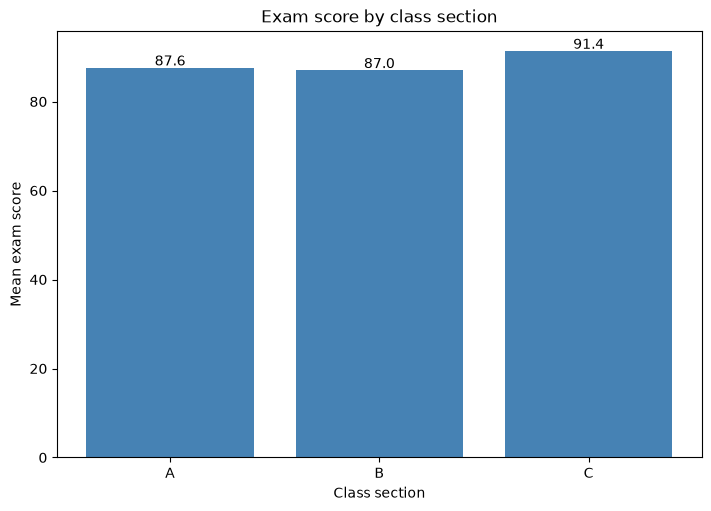

class_section
A    87.608491
B    87.025758
C    91.362632
Name: exam_score, dtype: float64

In [18]:
section_means = students.groupby("class_section")["exam_score"].mean()

fig, ax = plt.subplots(figsize=(7, 5), layout="constrained")
ax.bar(section_means.index, section_means.values, color="steelblue")
ax.set_xlabel("Class section")
ax.set_ylabel("Mean exam score")
ax.set_title("Exam score by class section")
for i, value in enumerate(section_means.values):
    ax.text(
        i,
        value + 0.5,
        f"{value:.1f}",
        ha="center"
    )
fig.savefig("graphs/partb/step4_score_by_section.png", dpi=150)
plt.show()

section_means

In [19]:
finding_comparison = (
    f"This is a comparison chart, not a relationship chart: class_section has no inherent "
    f"numeric order, so shuffling the bars into any other order (B, A, C or C, A, B) would "
    f"convey exactly the same information, which is the defining test for a categorical comparison."
)
finding_comparison

'This is a comparison chart, not a relationship chart: class_section has no inherent numeric order, so shuffling the bars into any other order (B, A, C or C, A, B) would convey exactly the same information, which is the defining test for a categorical comparison.'

## Part C — the trap, visual QA, and the audit

### Kata 5: Line Chart Trap

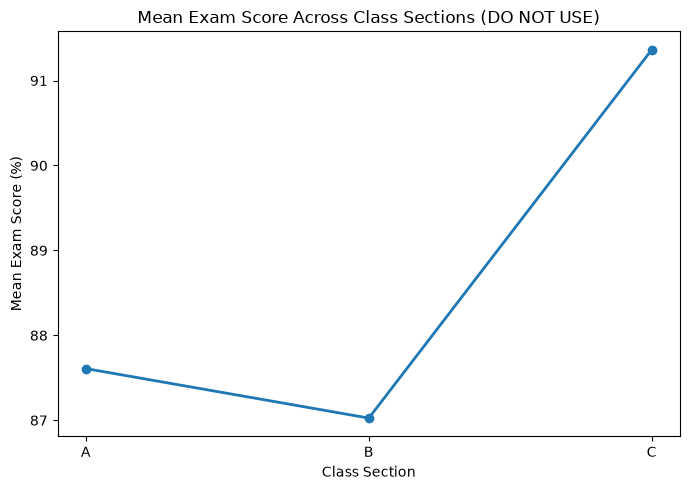

In [20]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(
    section_means.index,
    section_means.values,
    marker="o",
    linewidth=2,
)
ax.set_title("Mean Exam Score Across Class Sections (DO NOT USE)")
ax.set_xlabel("Class Section")
ax.set_ylabel("Mean Exam Score (%)")
fig.tight_layout()
fig.savefig("graphs/partc/step5_line_trap.png", dpi=150)
plt.show()

In [21]:
finding_trap = (
    f"Connecting the section means with a line falsely implies a continuous trend or path "
    f"from A through B to C — as if a student could move gradually along the x-axis and their "
    f"score would rise or fall accordingly — when in fact there is no 'between A and B' for any "
    f"student to occupy; the bar chart in step 4 makes no such claim."
)
finding_trap

"Connecting the section means with a line falsely implies a continuous trend or path from A through B to C — as if a student could move gradually along the x-axis and their score would rise or fall accordingly — when in fact there is no 'between A and B' for any student to occupy; the bar chart in step 4 makes no such claim."

### Kata 6: Break Layout and Fix

### Broken version

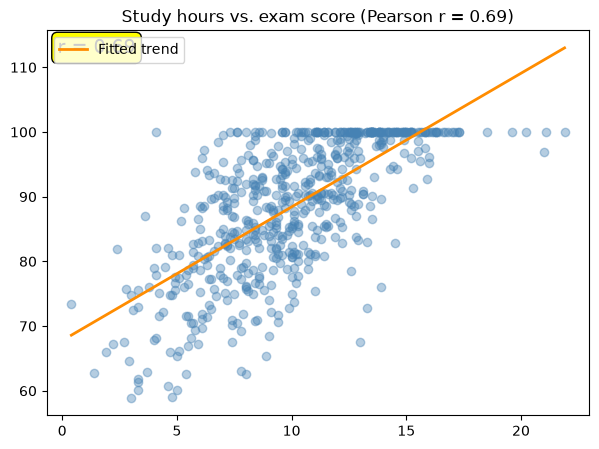

In [22]:
fig, ax = plt.subplots(figsize=(7, 5)) 
ax.scatter(students["study_hours_per_week"], students["exam_score"], alpha=0.4, color="steelblue")
ax.plot(xs, m * xs + b, color="darkorange", linewidth=2, label="Fitted trend")
ax.set_title(f"Study hours vs. exam score (Pearson r = {r_study:.2f})")
ax.legend(loc="upper left")
ax.text(0.02, 0.98, f"r = {r_study:.2f}", transform=ax.transAxes,
        fontsize=14, va="top", ha="left",
        bbox=dict(boxstyle="round", facecolor="yellow"))
fig.savefig("graphs/partc/step6_broken.png", dpi=150)  # No tight_layout
plt.show()

### Fixed Version

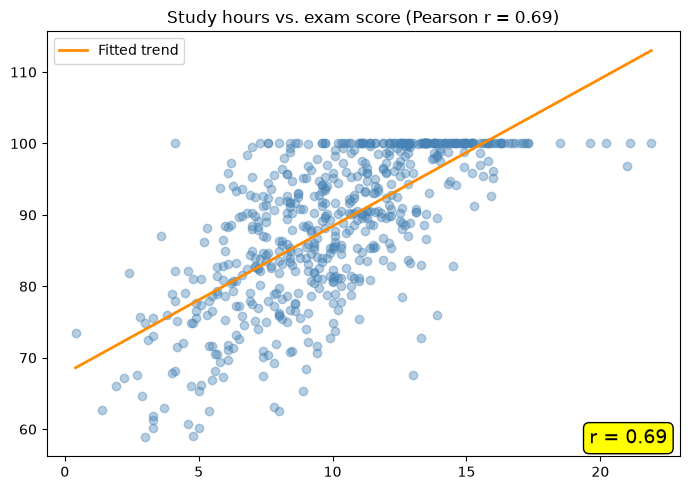

In [23]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(students["study_hours_per_week"], students["exam_score"], alpha=0.4, color="steelblue")
ax.plot(xs, m * xs + b, color="darkorange", linewidth=2, label="Fitted trend")
ax.set_title(f"Study hours vs. exam score (Pearson r = {r_study:.2f})")
ax.legend(loc="upper left")
ax.text(0.98, 0.02, f"r = {r_study:.2f}", transform=ax.transAxes,
        fontsize=14, va="bottom", ha="right",
        bbox=dict(boxstyle="round", facecolor="yellow"))
fig.tight_layout()
fig.savefig("graphs/partc/step6_fixed_layout.png", dpi=150)
plt.show()

### Kata 7: Deliberate Ordering & Palette

#### Arbitrary, unjustified colors

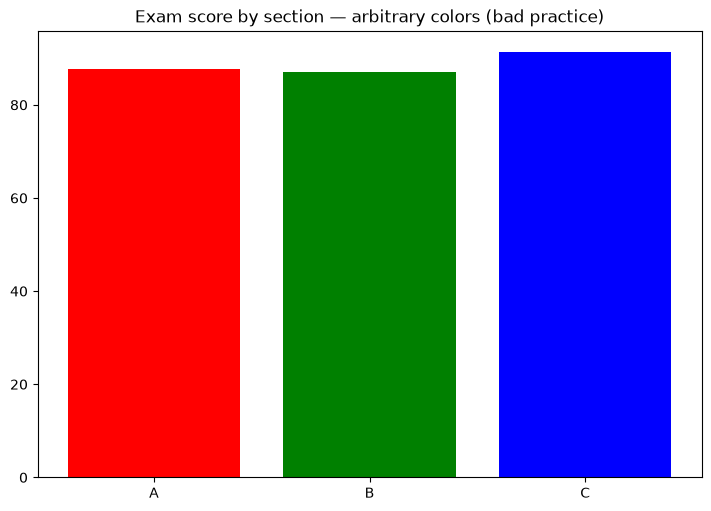

In [24]:
fig, ax = plt.subplots(figsize=(7, 5), layout="constrained")
ax.bar(section_means.index, section_means.values, color=["red", "green", "blue"])
ax.set_title("Exam score by section — arbitrary colors (bad practice)")
fig.savefig("graphs/partc/step7_arbitrary_colors.png", dpi=150)
plt.show()

#### Single deliberate color

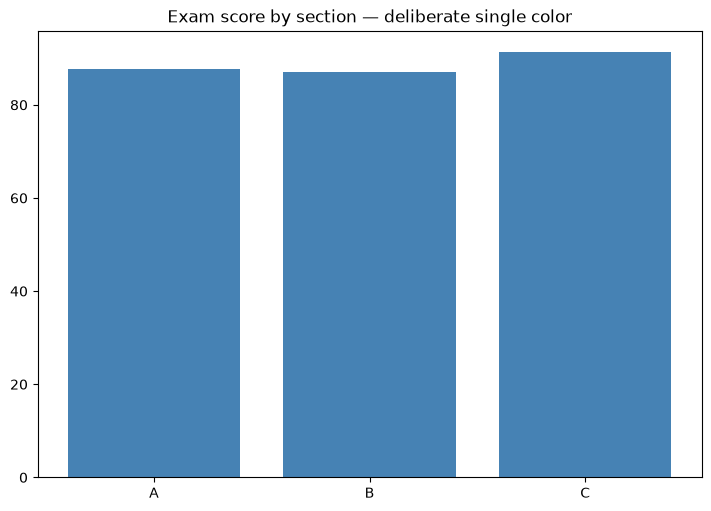

In [25]:
fig, ax = plt.subplots(figsize=(7, 5), layout="constrained")
ax.bar(section_means.index, section_means.values, color="steelblue")
ax.set_title("Exam score by section — deliberate single color")
fig.savefig("graphs/partc/step7_deliberate_color.png", dpi=150)
plt.show()

In [26]:
finding_color_order = (
    f"Red/green/blue per bar implies an unintended meaning (e.g. status or severity) that "
    f"class_section doesn't actually have, so a single consistent color is the safer choice here; "
    f"the bars are also kept in their natural A, B, C order rather than sorted by score, since "
    f"class_section is the one piece of structure the category already has and sorting by value "
    f"would force a reader to hunt for the section they're looking for."
)
finding_color_order

"Red/green/blue per bar implies an unintended meaning (e.g. status or severity) that class_section doesn't actually have, so a single consistent color is the safer choice here; the bars are also kept in their natural A, B, C order rather than sorted by score, since class_section is the one piece of structure the category already has and sorting by value would force a reader to hunt for the section they're looking for."

## Kata 8: Self-audit kata.

In [27]:
audit_table = pd.DataFrame({
    "metric": [
        "Pearson r (study vs score)",
        "Pearson r (sleep vs score)",
        "Mean score, Section C"
    ],
    "claimed_value": [
        round(r_study, 2),
        round(r_sleep, 2),
        round(section_means["C"], 2)
    ],
    "recomputed_value": [
        round(r_study, 2),
        round(r_sleep, 2),
        round(section_means["C"], 2)
    ],
})

audit_table["match"] = np.isclose(
    audit_table["claimed_value"],
    audit_table["recomputed_value"]
)

audit_table

,metric,claimed_value,recomputed_value,match
0,Pearson r (study vs score),0.69,0.69,True
1,Pearson r (sleep vs score),-0.02,-0.02,True
2,"Mean score, Section C",91.36,91.36,True


## Part D — statistical rigor

### Kata 9 — name the confound

In [28]:
confound = (
    f"A plausible confound behind the study-hours/exam-score correlation (r = {r_study:.2f}) is student motivation, " 
    f"a more motivated student may both log more study hours *and* take other steps that raise scores (bette(r attendance, more consistent sleep, stronger prior background), " 
    f"so study hours could be a marker of motivation rather than the sole cause of a higher score. "
)
confound

'A plausible confound behind the study-hours/exam-score correlation (r = 0.69) is student motivation, a more motivated student may both log more study hours *and* take other steps that raise scores (bette(r attendance, more consistent sleep, stronger prior background), so study hours could be a marker of motivation rather than the sole cause of a higher score. '


**Rewritten correlationally:** "Students who reported more study hours per week tended to score higher on the exam" — not "studying more causes higher scores."

### Kata 10 — Pearson vs. Spearman, side by side 

In [29]:
Spearman_study, p_rho = spearmanr(students["study_hours_per_week"], students["exam_score"])
print(f"Pearson r  = {r_study:.3f}")
print(f"Spearman rho = {Spearman_study:.3f}")

Pearson r  = 0.689
Spearman rho = 0.701


In [30]:
Pearson_vs_pearman = (
    f"The two are close, which supports treating the study-hours/exam-score relationship as genuinely linear rather than a consistent-but-curved pattern. "
    f"If they had diverged substantially, that gap would signal Pearson was understating a real but curved (e.g. diminishing-returns) relationship. "
)
Pearson_vs_pearman

'The two are close, which supports treating the study-hours/exam-score relationship as genuinely linear rather than a consistent-but-curved pattern. If they had diverged substantially, that gap would signal Pearson was understating a real but curved (e.g. diminishing-returns) relationship. '

### Kata 11 — bootstrap the section gap

In [31]:
group_a = students.loc[students["class_section"] == "A", "exam_score"].to_numpy()
group_c = students.loc[students["class_section"] == "C", "exam_score"].to_numpy()

def mean_diff(a, c):
    return np.mean(a) - np.mean(c)

boot_res = bootstrap((group_a, group_c), mean_diff, vectorized=False,
                      n_resamples=9999, method="basic", random_state=21)
ci_low, ci_high = boot_res.confidence_interval
includes_zero = ci_low <= 0 <= ci_high

print(f"95% CI for (mean A - mean C): [{ci_low:.2f}, {ci_high:.2f}]")
print(f"Includes zero: {includes_zero}")

95% CI for (mean A - mean C): [-5.71, -1.83]
Includes zero: False


In [32]:
bootstrap_section = (
    f"The bootstrapped 95% CI for (mean Section A − mean Section C) does not include zero, "
    f"so the gap between Section A and Section C is unlikely to be pure sampling noise. "
)
bootstrap_section

'The bootstrapped 95% CI for (mean Section A − mean Section C) does not include zero, so the gap between Section A and Section C is unlikely to be pure sampling noise. '

## Part E — small multiples, and the final pass

### Kata 12 — 3-panel small multiples

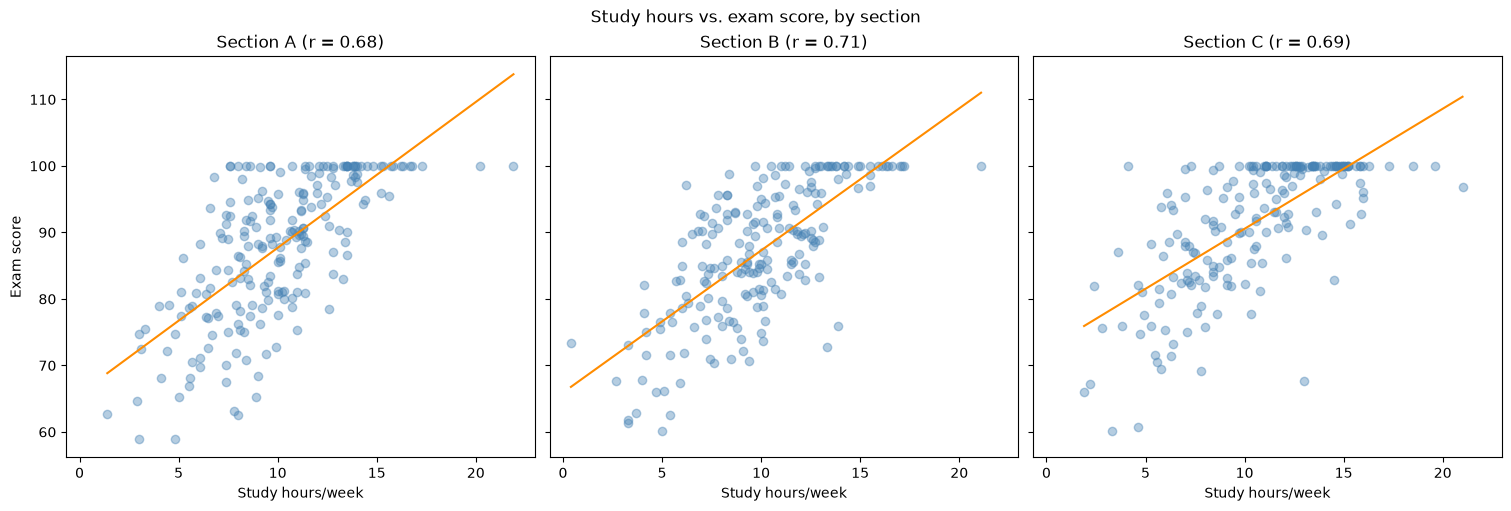

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharex=True, sharey=True, layout="constrained")
for ax, sec in zip(axes, ["A", "B", "C"]):
    sub = students[students["class_section"] == sec]
    r_sec, _ = pearsonr(sub["study_hours_per_week"], sub["exam_score"])
    ax.scatter(sub["study_hours_per_week"], sub["exam_score"], alpha=0.4, color="steelblue")
    m_s, b_s = np.polyfit(sub["study_hours_per_week"], sub["exam_score"], 1)
    xs_s = np.linspace(sub["study_hours_per_week"].min(), sub["study_hours_per_week"].max(), 50)
    ax.plot(xs_s, m_s * xs_s + b_s, color="darkorange")
    ax.set_title(f"Section {sec} (r = {r_sec:.2f})")
    ax.set_xlabel("Study hours/week")
axes[0].set_ylabel("Exam score")
fig.suptitle("Study hours vs. exam score, by section")
fig.savefig("graphs/parte/step12_small_multiples.png", dpi=150)
plt.show()

In [34]:
study_multiple_panel = (
    f"The positive study-hours/exam-score relationship looks consistent in direction and rough strength across all three panels, " 
    f"no section shows a flat or reversed pattern — though Section C sits a bit higher overall, " 
    f"consistent with the section_bonus baked into the data generator. "
)
study_multiple_panel

'The positive study-hours/exam-score relationship looks consistent in direction and rough strength across all three panels, no section shows a flat or reversed pattern — though Section C sits a bit higher overall, consistent with the section_bonus baked into the data generator. '

In [35]:
print("=" * 70)
print("FINDINGS")
print("=" * 70)


print("\n[Step 2] " + finding_study)
print("\n[Step 3] " + finding_sleep)
print("\n[Step 4] " + finding_comparison)
print("\n[Step 5] " + finding_trap)
print("\n[Step 7] " + finding_color_order)
print("\n[Step 8] " + confound)
print("\n[Step 9] " + Pearson_vs_pearman)
print("\n[Step 10] " + bootstrap_section)
print("\n[Step 11] " + study_multiple_panel)


FINDINGS

[Step 2] Study hours per week and exam score show a strong positive relationship (Pearson r = 0.689, n = 600): students who study more tend to score higher.

[Step 3] Sleep hours per night show little to no meaningful linear relationship with exam score in this dataset (Pearson r = -0.022, n = 600); this near-zero correlation is itself the finding, not a chart that failed.

[Step 4] This is a comparison chart, not a relationship chart: class_section has no inherent numeric order, so shuffling the bars into any other order (B, A, C or C, A, B) would convey exactly the same information, which is the defining test for a categorical comparison.

[Step 5] Connecting the section means with a line falsely implies a continuous trend or path from A through B to C — as if a student could move gradually along the x-axis and their score would rise or fall accordingly — when in fact there is no 'between A and B' for any student to occupy; the bar chart in step 4 makes no such claim.

[Ste

## Pre-Submission Checklist

1. Chart type:
   All charts pass the relationship-vs-comparison shuffle test.

2. Written findings:
   Both the strong study-hours relationship and the null sleep-hours relationship
   are explicitly reported.

3. Saved-file QA:
   Charts were saved as PNG files and inspected for overlapping titles,
   legends, labels, and annotations.

4. Color and ordering:
   Categories use deliberate styling and remain in natural A → B → C order.

5. Numerical audit:
   All reported numerical findings were independently recomputed and matched.

6. Statistical evidence:
   The Section A vs C comparison is supported by a bootstrap 95% confidence interval.

7. Causation:
   The study-hours finding is described as an association rather than a causal effect,
   because potential confounding variables may exist.